# Dependencies

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, KFold, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, FunctionTransformer, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, OneSidedSelection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, balanced_accuracy_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import randint, uniform
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from xgbimputer import XGBImputer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from tabulate import tabulate
import matplotlib.pyplot as plt
import lightgbm as lgb
import catboost as cb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import os
import joblib 
import optuna
from optuna.samplers import TPESampler
import numpy as np
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', 200)


# Load

In [4]:
# app_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/application_record.csv")
# cred_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/credit_record.csv")

app_df = pd.read_csv("D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\Dataset\\raw\\application_record.csv")
cred_df = pd.read_csv("D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\Dataset\\raw\\credit_record.csv")

In [5]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
cred_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [7]:
cred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


# Creating Target

In [8]:
is_bad = (
    cred_df['STATUS']
    .isin(['3','4','5'])
    .groupby(cred_df['ID'])
    .max()  # Jika ada minimal 1 True, return 1
    .astype(int)
)

# Aggregrating Credit Records

In [9]:
credit_agg = cred_df.groupby('ID').agg(
    CREDIT_HISTORY_LENGTH=('MONTHS_BALANCE', lambda x: abs(x.min() - x.max()) + 1)).reset_index()
    
# Gabungkan target dengan fitur agregasi kredit
credit_agg['IS_BAD'] = is_bad.values

In [10]:
cred_df['MONTHS_BALANCE'].describe()


count    1.048575e+06
mean    -1.913700e+01
std      1.402350e+01
min     -6.000000e+01
25%     -2.900000e+01
50%     -1.700000e+01
75%     -7.000000e+00
max      0.000000e+00
Name: MONTHS_BALANCE, dtype: float64

In [11]:
credit_agg

,ID,CREDIT_HISTORY_LENGTH,IS_BAD
0,5001711,4,0
1,5001712,19,0
2,5001713,22,0
3,5001714,15,0
4,5001715,60,0
...,...,...,...
45980,5150482,18,0
45981,5150483,18,0
45982,5150484,13,0
45983,5150485,2,0


# Merge Data

In [12]:
new_df = pd.merge(app_df, credit_agg, on="ID", how="inner")

In [13]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,16,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,15,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,0


In [14]:
new_df.isna().sum()

ID                           0
CODE_GENDER                  0
FLAG_OWN_CAR                 0
FLAG_OWN_REALTY              0
CNT_CHILDREN                 0
AMT_INCOME_TOTAL             0
NAME_INCOME_TYPE             0
NAME_EDUCATION_TYPE          0
NAME_FAMILY_STATUS           0
NAME_HOUSING_TYPE            0
DAYS_BIRTH                   0
DAYS_EMPLOYED                0
FLAG_MOBIL                   0
FLAG_WORK_PHONE              0
FLAG_PHONE                   0
FLAG_EMAIL                   0
OCCUPATION_TYPE          11323
CNT_FAM_MEMBERS              0
CREDIT_HISTORY_LENGTH        0
IS_BAD                       0
dtype: int64

In [15]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   AMT_INCOME_TOTAL       36457 non-null  float64
 6   NAME_INCOME_TYPE       36457 non-null  object 
 7   NAME_EDUCATION_TYPE    36457 non-null  object 
 8   NAME_FAMILY_STATUS     36457 non-null  object 
 9   NAME_HOUSING_TYPE      36457 non-null  object 
 10  DAYS_BIRTH             36457 non-null  int64  
 11  DAYS_EMPLOYED          36457 non-null  int64  
 12  FLAG_MOBIL             36457 non-null  int64  
 13  FLAG_WORK_PHONE        36457 non-null  int64  
 14  FLAG_PHONE             36457 non-null  int64  
 15  FL

In [16]:
new_df = new_df.dropna()

In [17]:
new_df["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.991923
1    0.008077
Name: proportion, dtype: float64

In [18]:
new_df["IS_BAD"].value_counts()

IS_BAD
0    24931
1      203
Name: count, dtype: int64

In [19]:
for column in new_df.select_dtypes(include='object'):
    unique_values = new_df[column].unique()
    print(f"Unique values in {column}: {unique_values}")

Unique values in CODE_GENDER: ['M' 'F']
Unique values in FLAG_OWN_CAR: ['Y' 'N']
Unique values in FLAG_OWN_REALTY: ['Y' 'N']
Unique values in NAME_INCOME_TYPE: ['Working' 'Commercial associate' 'State servant' 'Student' 'Pensioner']
Unique values in NAME_EDUCATION_TYPE: ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
Unique values in NAME_FAMILY_STATUS: ['Married' 'Single / not married' 'Civil marriage' 'Separated' 'Widow']
Unique values in NAME_HOUSING_TYPE: ['House / apartment' 'Rented apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
Unique values in OCCUPATION_TYPE: ['Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


# Renaming Feature

In [20]:
new_df = new_df.rename(columns={
    "DAYS_BIRTH" : "AGE",
    "NAME_FAMILY_STATUS" : "MARITAL_STATUS",
    "NAME_HOUSING_TYPE" :  "DWELLING_TYPE",
    "AMT_INCOME_TOTAL" : "ANNUAL_INCOME",
    "OCCUPATION_TYPE" : "JOB_TITLE",
    "NAME_EDUCATION_TYPE" : "EDUCATION_LEVEL",
    "DAYS_EMPLOYED" : "EMPLOYMENT_LENGTH",
    "NAME_INCOME_TYPE" : "EMPLOYMENT_STATUS"})

In [21]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,27,0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,0


In [22]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25134 entries, 2 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     25134 non-null  int64  
 1   CODE_GENDER            25134 non-null  object 
 2   FLAG_OWN_CAR           25134 non-null  object 
 3   FLAG_OWN_REALTY        25134 non-null  object 
 4   CNT_CHILDREN           25134 non-null  int64  
 5   ANNUAL_INCOME          25134 non-null  float64
 6   EMPLOYMENT_STATUS      25134 non-null  object 
 7   EDUCATION_LEVEL        25134 non-null  object 
 8   MARITAL_STATUS         25134 non-null  object 
 9   DWELLING_TYPE          25134 non-null  object 
 10  AGE                    25134 non-null  int64  
 11  EMPLOYMENT_LENGTH      25134 non-null  int64  
 12  FLAG_MOBIL             25134 non-null  int64  
 13  FLAG_WORK_PHONE        25134 non-null  int64  
 14  FLAG_PHONE             25134 non-null  int64  
 15  FLAG_EM

In [23]:
df_retire = new_df[new_df['EMPLOYMENT_STATUS'] == 'Pensioner']
df_retire

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
36120,5010868,M,Y,Y,1,450000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-18173,-678,1,0,1,1,Core staff,3.0,17,1
36191,5045929,M,N,N,0,247500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-15037,-2208,1,0,0,0,Laborers,1.0,31,0
36195,5046328,F,N,Y,1,157500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-15466,-2269,1,0,1,0,Low-skill Laborers,3.0,13,1
36234,5054386,M,Y,N,0,292500.0,Pensioner,Higher education,Single / not married,House / apartment,-14050,-3680,1,1,1,0,Laborers,1.0,42,0
36300,5092394,M,Y,Y,1,157500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-11050,-443,1,1,0,0,Drivers,3.0,20,0
36340,5105739,F,N,Y,3,292500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-12368,-672,1,0,0,0,Core staff,5.0,22,0
36362,5115455,F,Y,Y,0,270000.0,Pensioner,Higher education,Married,House / apartment,-17833,-620,1,0,1,0,Accountants,2.0,26,0
36374,5116906,M,Y,Y,0,211500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-15047,-7553,1,0,0,0,Core staff,2.0,15,1
36375,5116907,M,Y,Y,0,211500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-15047,-7553,1,0,0,0,Core staff,2.0,8,0
36394,5118648,F,N,Y,2,270000.0,Pensioner,Higher education,Single / not married,House / apartment,-10425,-2745,1,0,0,0,Core staff,3.0,37,0


In [24]:
# split the data into train and test
def data_split(df, test_size):
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=42)
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

In [25]:
train_original, test_original = data_split(new_df, 0.2)

In [26]:
train_original["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.991893
1    0.008107
Name: proportion, dtype: float64

In [27]:
test_original["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.992043
1    0.007957
Name: proportion, dtype: float64

In [28]:
encoded_df = new_df.copy()
label_encoder = LabelEncoder()
for col in encoded_df.select_dtypes(include=['object']).columns:
    encoded_df[col] = label_encoder.fit_transform(encoded_df[col])

encoded_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
2,5008806,1,1,1,0,112500.0,4,4,1,1,-21474,-1134,1,0,0,0,16,2.0,30,0
3,5008808,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,5,0
4,5008809,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,5,0
5,5008810,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,27,0
6,5008811,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,1,1,1,0,315000.0,4,4,1,1,-17348,-2420,1,0,0,0,10,2.0,12,1
36453,5149834,0,0,1,0,157500.0,0,1,1,1,-12387,-1325,1,0,1,1,11,2.0,24,1
36454,5149838,0,0,1,0,157500.0,1,1,1,1,-12387,-1325,1,0,1,1,11,2.0,33,1
36455,5150049,0,0,1,0,283500.0,4,4,1,1,-17958,-655,1,0,0,0,14,2.0,10,0


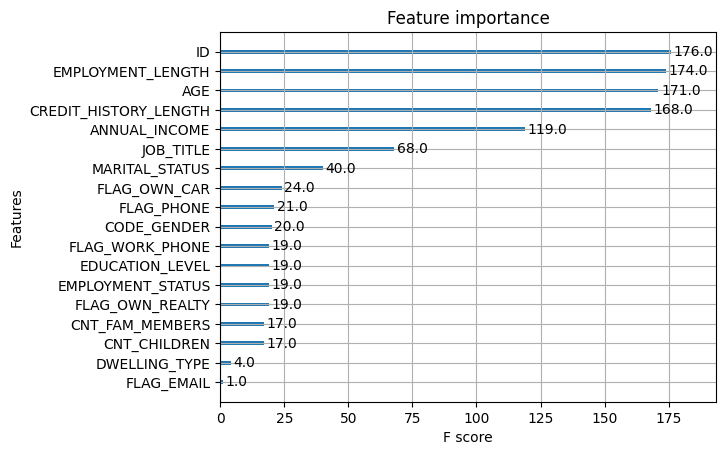

In [29]:
X = encoded_df.drop("IS_BAD", axis=1)
y = encoded_df["IS_BAD"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Train model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
model.fit(X_test, y_test)


# # Plot feature importance
plot_importance(model)
# Atur ukuran figure
# plt.figure(figsize=(10, 20))  # Lebar 10, tinggi 12
plt.yticks(rotation=0)  # Bisa diganti ke 45 atau 90 jika perlu
plt.show()


In [30]:
print(encoded_df.corr()['IS_BAD'].sort_values(ascending=False))


IS_BAD                   1.000000
CREDIT_HISTORY_LENGTH    0.082017
EMPLOYMENT_LENGTH        0.024866
MARITAL_STATUS           0.022718
ID                       0.019119
CODE_GENDER              0.013969
FLAG_PHONE               0.013250
FLAG_EMAIL               0.008223
ANNUAL_INCOME            0.007944
FLAG_WORK_PHONE          0.002408
FLAG_OWN_CAR            -0.000842
AGE                     -0.001745
CNT_CHILDREN            -0.002259
DWELLING_TYPE           -0.004538
CNT_FAM_MEMBERS         -0.008301
JOB_TITLE               -0.009819
EDUCATION_LEVEL         -0.010207
FLAG_OWN_REALTY         -0.010239
EMPLOYMENT_STATUS       -0.012135
FLAG_MOBIL                    NaN
Name: IS_BAD, dtype: float64


In [31]:
X_train.shape

(20107, 19)

In [32]:
y_train.shape

(20107,)

# List of Feature Preprocessing

ID:
* Drop the feature

CODE_GENDER: 
* Drop Feature

AGE from DAYS_BIRTH: 
* Abs value and div 365.25

MARITAL_STATUS from NAME_FAMILY_STATUS: 
* One hot encoding

CNT_FAM_MEMBERS:
* Raw

CNT_CHILDERN:
* Drop feature

DWELLING_TYPE from NAME_HOUSING_TYPE 
* One hot encoding

ANNUAL_INCOME from AMT_INCOME_TOTAL:
* Raw

JOB_TITLE from OCCUPATION_TYPE 
* One hot encoding

EMPLOYMENT_STATUS from NAME_INCOME_TYPE: 
* One hot encoding

EDUCATION_LEVEL from NAME_EDUCATION TYPE: 
* Ordinal encoding

EMPLOYMENT_LENGTH from DAYS_EMPLOYED: 
* Abs value and div 365.25
* change days of employments of retirees to 0

FLAG_OWN_CAR: 
* Change it numerical

FLAG_OWN_REALTY: 
* Change it numerical

FLAG_MOBILE: 
* Drop feature (because all of it is 1) 

FLAG_WORK_PHONE : 
* Raw

FLAG_PHONE: 
* Drop feature

FLAG_EMAIL: 
* Drop Feature

IS_BAD: 
* Balancing with Oversampling

# Preprocessing Data

In [33]:
# Improved outlier remover with configurable IQR multiplier
class OutlierRemover(BaseEstimator, TransformerMixin):
    def __init__(self, features, iqr_multiplier=3.0):
        self.features = features
        self.iqr_multiplier = iqr_multiplier
        self.Q1 = None
        self.Q3 = None
        self.IQR = None

    def fit(self, X, y=None):
        self.Q1 = X[self.features].quantile(0.25)
        self.Q3 = X[self.features].quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        return self

    def transform(self, X, y=None):
        mask = ~((X[self.features] < (self.Q1 - self.iqr_multiplier * self.IQR)) | 
                 (X[self.features] > (self.Q3 + self.iqr_multiplier * self.IQR))).any(axis=1)

        # If y is provided, return filtered X and y
        if y is not None:
            return X[mask], y[mask]
        return X[mask]


In [34]:
# Improved column dropper
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[f for f in self.features if f in X.columns], errors='ignore')

In [35]:
# Improved time converter with configurable divisor
class TimeConverter(BaseEstimator, TransformerMixin):
    def __init__(self, features, divisor=365.25):
        self.features = features
        self.divisor = divisor

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.features] = X_copy[self.features].abs() // self.divisor
        return X_copy

In [36]:
# Improved retiree handler
class HandleRetirees(BaseEstimator, TransformerMixin):
    def __init__(self, employment_length_col='EMPLOYMENT_LENGTH', retirement_value=365243):
        self.employment_length_col = employment_length_col
        self.retirement_value = retirement_value
        
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy.loc[X_copy[self.employment_length_col] == self.retirement_value, self.employment_length_col] = 0
        return X_copy

In [37]:
# Improved skewness adjuster with configurable transformation
class AdjustSkewness(BaseEstimator, TransformerMixin):
    def __init__(self, features, method='cbrt'):
        self.features = features
        self.method = method  # 'cbrt', 'log', or 'sqrt'

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        
        if self.method == 'cbrt':
            X_copy[self.features] = np.cbrt(X_copy[self.features])
        elif self.method == 'log':
            # Add small constant to avoid log(0)
            X_copy[self.features] = np.log1p(X_copy[self.features])
        elif self.method == 'sqrt':
            X_copy[self.features] = np.sqrt(X_copy[self.features])
            
        return X_copy

In [38]:
# Improved feature binarizer
class BinarizeFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, features, mapping=None):
        self.features = features
        self.mapping = mapping or {'Y': 1, 'N' : 0}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        for feature in self.features:
            if feature in X_copy.columns:
                X_copy[feature] = X_copy[feature].map(self.mapping)
        return X_copy

In [39]:
# Improved one-hot encoder
class OneHotEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features, handle_unknown="ignore"):
        self.features = features
        self.encoder = OneHotEncoder(handle_unknown=handle_unknown, sparse_output=False)
        self.feature_names = None

    def fit(self, X, y=None):
        self.encoder.fit(X[self.features])
        self.feature_names = self.encoder.get_feature_names_out(self.features)
        return self

    def transform(self, X):
        encoded = self.encoder.transform(X[self.features])
        encoded_df = pd.DataFrame(encoded, 
                                columns=self.feature_names, 
                                index=X.index)
        return X.drop(columns=self.features).join(encoded_df)

In [40]:
# Improved ordinal encoder
class OrdinalEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, feature, mapping):
        self.feature = feature
        self.mapping = mapping
        self.default_value = -1  # Default value for unknown categories

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.feature] = X_copy[self.feature].map(self.mapping).fillna(self.default_value)
        return X_copy

In [41]:
# Improved scaler
class ScalerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features, scaler=None):
        self.features = features
        self.scaler = scaler or StandardScaler()

    def fit(self, X, y=None):
        self.scaler.fit(X[self.features])
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.features] = self.scaler.transform(X_copy[self.features])
        return X_copy

In [42]:
train_original

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
0,5095269,F,Y,Y,0,126000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-10302,-734,1,0,0,0,Core staff,2.0,46,0
1,5118242,M,N,N,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13739,-2896,1,0,0,0,Security staff,2.0,43,0
2,5023990,F,N,Y,1,157500.0,Working,Higher education,Married,House / apartment,-11099,-2011,1,0,0,0,Sales staff,3.0,10,0
3,5066561,F,N,N,0,180000.0,Commercial associate,Incomplete higher,Married,With parents,-8247,-430,1,1,0,1,Sales staff,2.0,15,0
4,5090651,F,N,Y,1,315000.0,Working,Higher education,Civil marriage,House / apartment,-10810,-1435,1,1,0,1,Core staff,3.0,21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20102,5132306,M,Y,Y,0,184500.0,Working,Secondary / secondary special,Married,House / apartment,-12298,-1200,1,0,0,0,Drivers,2.0,9,0
20103,5036687,M,N,Y,1,202500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-11105,-3000,1,0,0,0,High skill tech staff,3.0,10,0
20104,5010320,M,N,N,0,135000.0,Commercial associate,Higher education,Married,House / apartment,-9493,-130,1,0,0,1,Cooking staff,2.0,31,0
20105,5095340,M,N,Y,0,135000.0,Working,Higher education,Married,House / apartment,-20222,-218,1,0,0,0,Laborers,2.0,5,0


In [43]:
# Define features
numerical_features = ['AGE', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH', 'CREDIT_HISTORY_LENGTH', 'CNT_FAM_MEMBERS']
categorical_features = ['MARITAL_STATUS', 'JOB_TITLE', 'EMPLOYMENT_STATUS', 'DWELLING_TYPE']
outlier_features = ['CNT_FAM_MEMBERS', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH']

# Updated mapping for ordinal encoding
education_mapping = {
    'Lower secondary': 0, 
    'Secondary / secondary special': 1, 
    'Incomplete higher': 2,  
    'Higher education': 3, 
    'Academic degree': 4
}

# ML Algorithm

In [44]:
classifiers = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,  # Meningkatkan jumlah pohon untuk stabilitas
        max_depth=20,  # Meningkatkan kompleksitas tanpa overfitting
        min_samples_split=3,  # Mengurangi batas split agar lebih fleksibel
        min_samples_leaf=2,  
        max_features='log2',  # Memilih fitur lebih banyak
        class_weight={0:1, 1:6},  # Menyesuaikan balancing
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,  
        max_depth=25,  
        min_samples_split=3,  
        min_samples_leaf=2,  
        max_features='log2',  
        class_weight={0:1, 1:10},  
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,  
        max_depth=7,  
        learning_rate=0.05,  # Sedikit lebih tinggi untuk meningkatkan konvergensi
        subsample=0.9,  # Sedikit lebih tinggi agar lebih robust
        colsample_bytree=0.9,  
        scale_pos_weight=6,  # Lebih kecil agar tidak terlalu bias ke minoritas
        eval_metric="auc",  
        random_state=42, 
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=7,  
        learning_rate=0.05,  
        subsample=0.9,  
        colsample_bytree=0.9,  
        class_weight={0:1, 1:6},  
        random_state=42,  
        n_jobs=-1
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500,  
        depth=7,  
        learning_rate=0.05,  
        l2_leaf_reg=4,  
        verbose=0,  
        class_weights={0:1, 1:6},  
        random_state=42
    ),
}


In [45]:
df = (train_original[train_original["IS_BAD"] == 1])
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
85,5118441,F,Y,N,1,108000.0,Commercial associate,Higher education,Married,House / apartment,-16138,-431,1,1,0,0,Sales staff,3.0,42,1
375,5126012,F,N,N,0,270000.0,State servant,Secondary / secondary special,Married,House / apartment,-20103,-1444,1,1,1,0,Waiters/barmen staff,2.0,32,1
411,5135345,M,N,Y,0,112500.0,Commercial associate,Higher education,Married,House / apartment,-20103,-555,1,0,0,0,Security staff,2.0,50,1
722,5078805,F,N,Y,0,306000.0,Working,Secondary / secondary special,Married,House / apartment,-18927,-2978,1,0,0,0,High skill tech staff,2.0,34,1
736,5091281,M,N,Y,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-13645,-5374,1,0,0,0,Laborers,2.0,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19578,5029451,F,Y,Y,0,225000.0,Working,Higher education,Married,House / apartment,-17402,-3153,1,0,1,0,Core staff,2.0,53,1
19591,5115604,F,N,Y,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-14523,-3420,1,0,0,0,Core staff,2.0,5,1
19608,5146167,F,N,Y,0,135000.0,Working,Secondary / secondary special,Married,House / apartment,-20296,-1770,1,0,0,0,Security staff,2.0,21,1
19720,5142973,M,N,N,1,180000.0,Working,Secondary / secondary special,Married,House / apartment,-10656,-926,1,1,1,0,Laborers,1.0,19,1


# Best Model

In [46]:
# Create a preprocessing pipeline without sampling
preprocessing_pipeline = Pipeline([
    ('drop_columns', DropColumns(features=['ID', 'FLAG_MOBIL', 'CNT_CHILDREN', 'CODE_GENDER', 'FLAG_PHONE', 'FLAG_EMAIL', 'CREDIT_HISTORY_LENGTH'])),
    ('time_conversion', TimeConverter(features=['EMPLOYMENT_LENGTH', 'AGE'], divisor=365.25)),
    ('handle_retirees', HandleRetirees(employment_length_col='EMPLOYMENT_LENGTH', retirement_value=365243)),
    # ('adjust_skewness', AdjustSkewness(features=['ANNUAL_INCOME', 'AGE', 'CREDIT_HISTORY_LENGTH'], method='log')),
    ('binarize', BinarizeFeatures(features=['FLAG_OWN_CAR', 'FLAG_OWN_REALTY'], mapping={'Y' : 1, 'N' : 0})),
    ('one_hot_encoding', OneHotEncoderTransformer(features=categorical_features, handle_unknown='ignore')),
    ('ordinal_encoding', OrdinalEncoderTransformer(feature='EDUCATION_LEVEL', mapping=education_mapping)),
    # ('scaling', ScalerTransformer(features=numerical_features))
])

In [47]:
# Function to optimize Random Forest hyperparameters
def optimize_random_forest(trial, X_train, X_test, y_train, y_test):
    # Define the hyperparameters to optimize
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    max_depth = trial.suggest_int('max_depth', 5, 30, step=1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10, step=1)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # For imbalanced data, we need to prioritize the minority class
    # Higher weight for class 1 (bad loan)
    pos_weight = trial.suggest_int('pos_weight', 5, 20, step=1)
    class_weight = {0: 1, 1: pos_weight}
    
    # Create and train the model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Find the threshold that gives at least 90% recall
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Start with a high threshold and decrease until we reach desired recall
    for threshold in np.arange(0.1, 0.01, -0.01):
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
        if recall >= 0.75:  # We want at least 75% recall
            break
    
    # If no threshold found, set a very low one to prioritize recall
    if 'threshold' not in locals():
        threshold = 0.01
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
    
    # Calculate other metrics
    precision = precision_score(y_test, y_pred)
    f2_score = fbeta_score(y_test, y_pred, beta=2.0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    # Return the metrics and model
    return {
        'model': model,
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f2_score': f2_score,
        'balanced_accuracy': balanced_acc
    }

In [48]:
# Function to optimize Extra Trees hyperparameters
def optimize_extra_trees(trial, X_train, X_test, y_train, y_test):
    # Define the hyperparameters to optimize
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    max_depth = trial.suggest_int('max_depth', 5, 30, step=1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10, step=1)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # For imbalanced data, we need to prioritize the minority class
    pos_weight = trial.suggest_int('pos_weight', 5, 20, step=1)
    class_weight = {0: 1, 1: pos_weight}
    
    # Create and train the model
    model = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Find the threshold that gives at least 75% recall
    y_proba = model.predict_proba(X_test)[:, 1]
    
    for threshold in np.arange(0.1, 0.01, -0.01):
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
        if recall >= 0.75:
            break
    
    if 'threshold' not in locals():
        threshold = 0.01
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    f2_score = fbeta_score(y_test, y_pred, beta=2.0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    return {
        'model': model,
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f2_score': f2_score,
        'balanced_accuracy': balanced_acc
    }

In [49]:
# Function to optimize XGBoost hyperparameters
def optimize_xgboost(trial, X_train, X_test, y_train, y_test):
    # Define the hyperparameters to optimize
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    max_depth = trial.suggest_int('max_depth', 3, 10, step=1)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    
    # For imbalanced data
    scale_pos_weight = trial.suggest_int('scale_pos_weight', 5, 20, step=1)
    
    # Create and train the model
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Find the threshold that gives at least 75% recall
    y_proba = model.predict_proba(X_test)[:, 1]
    
    for threshold in np.arange(0.1, 0.01, -0.01):
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
        if recall >= 0.75:
            break
    
    if 'threshold' not in locals():
        threshold = 0.01
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    f2_score = fbeta_score(y_test, y_pred, beta=2.0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    return {
        'model': model,
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f2_score': f2_score,
        'balanced_accuracy': balanced_acc
    }

In [50]:
# Function to optimize LightGBM hyperparameters
def optimize_lightgbm(trial, X_train, X_test, y_train, y_test):
    # Define the hyperparameters to optimize
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    max_depth = trial.suggest_int('max_depth', 3, 10, step=1)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    
    # For imbalanced data
    pos_weight = trial.suggest_int('pos_weight', 5, 20, step=1)
    class_weight = {0: 1, 1: pos_weight}
    
    # Create and train the model
    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Find the threshold that gives at least 75% recall
    y_proba = model.predict_proba(X_test)[:, 1]
    
    for threshold in np.arange(0.1, 0.01, -0.01):
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
        if recall >= 0.75:
            break
    
    if 'threshold' not in locals():
        threshold = 0.01
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    f2_score = fbeta_score(y_test, y_pred, beta=2.0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    return {
        'model': model,
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f2_score': f2_score,
        'balanced_accuracy': balanced_acc
    }

In [51]:
# Function to optimize CatBoost hyperparameters
def optimize_catboost(trial, X_train, X_test, y_train, y_test):
    # Define the hyperparameters to optimize
    iterations = trial.suggest_int('iterations', 100, 1000, step=100)
    depth = trial.suggest_int('depth', 3, 10, step=1)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    l2_leaf_reg = trial.suggest_int('l2_leaf_reg', 1, 10)
    
    # For imbalanced data
    pos_weight = trial.suggest_int('pos_weight', 5, 20, step=1)
    class_weights = {0: 1, 1: pos_weight}
    
    # Create and train the model
    model = cb.CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        verbose=0,
        class_weights=class_weights,
        random_state=42,
        thread_count=-1,
    )
    
    model.fit(X_train, y_train)
    
    # Find the threshold that gives at least 75% recall
    y_proba = model.predict_proba(X_test)[:, 1]
    
    for threshold in np.arange(0.1, 0.01, -0.01):
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
        if recall >= 0.75:
            break
    
    if 'threshold' not in locals():
        threshold = 0.01
        y_pred = (y_proba >= threshold)
        recall = recall_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    f2_score = fbeta_score(y_test, y_pred, beta=2.0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    return {
        'model': model,
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f2_score': f2_score,
        'balanced_accuracy': balanced_acc
    }

In [52]:
# Function to create an objective function for a specific model type
def create_objective(model_type, X_train, X_test, y_train, y_test):
    def objective(trial):
        if model_type == "Random Forest":
            result = optimize_random_forest(trial, X_train, X_test, y_train, y_test)
        elif model_type == "Extra Trees":
            result = optimize_extra_trees(trial, X_train, X_test, y_train, y_test)
        elif model_type == "XGBoost":
            result = optimize_xgboost(trial, X_train, X_test, y_train, y_test)
        elif model_type == "LightGBM":
            result = optimize_lightgbm(trial, X_train, X_test, y_train, y_test)
        elif model_type == "CatBoost":
            result = optimize_catboost(trial, X_train, X_test, y_train, y_test)
        else:
            raise ValueError(f"Unknown model type: {model_type}")
        
        # Our primary metric is F2 score, which puts more emphasis on recall
        # But we also want to ensure the recall is at least 75%
        if result['recall'] < 0.75:
            # If recall is less than 75%, return a very low score
            return -100
        
        # Otherwise, return F2 score as the objective value to maximize
        return result['f2_score']
    
    return objective

In [53]:
# Function to run Optuna optimization for all classifiers
def optimize_all_classifiers(X_train, X_test, y_train, y_test, n_trials=50):
    results = {}
    
    for model_name in ["Random Forest", "Extra Trees", "XGBoost", "LightGBM", "CatBoost"]:
        print(f"\nOptimizing {model_name}...")
        
        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=42),
            study_name=f"{model_name} optimization"
        )
        
        objective = create_objective(model_name, X_train, X_test, y_train, y_test)
        study.optimize(objective, n_trials=n_trials)
        
        print(f"Best value: {study.best_value:.4f}")
        print(f"Best hyperparameters: {study.best_params}")
        
        # Retrieve the best model and its metrics
        if model_name == "Random Forest":
            best_result = optimize_random_forest(study.best_trial, X_train, X_test, y_train, y_test)
        elif model_name == "Extra Trees":
            best_result = optimize_extra_trees(study.best_trial, X_train, X_test, y_train, y_test)
        elif model_name == "XGBoost":
            best_result = optimize_xgboost(study.best_trial, X_train, X_test, y_train, y_test)
        elif model_name == "LightGBM":
            best_result = optimize_lightgbm(study.best_trial, X_train, X_test, y_train, y_test)
        elif model_name == "CatBoost":
            best_result = optimize_catboost(study.best_trial, X_train, X_test, y_train, y_test)
        
        results[model_name] = {
            'model': best_result['model'],
            'threshold': best_result['threshold'],
            'metrics': {
                'recall': best_result['recall'],
                'precision': best_result['precision'],
                'f2_score': best_result['f2_score'],
                'balanced_accuracy': best_result['balanced_accuracy']
            },
            'hyperparameters': study.best_params
        }
        
    return results

In [54]:
def apply_resampling(X_train, y_train, method):
    if method == 'SMOTE':
        sampler = SMOTE(sampling_strategy=0.7, random_state=42)
    elif method == 'ADASYN':
        sampler = ADASYN(sampling_strategy=0.7, random_state=42)
    elif method == 'RandomOverSampler':
        sampler = RandomOverSampler(sampling_strategy=0.7, random_state=42)
    elif method == 'SMOTETomek':
        sampler = SMOTETomek(sampling_strategy=0.7, random_state=42)
    else:
        raise ValueError("Unknown resampling method")
    
    return sampler.fit_resample(X_train, y_train)

Training data shape after outlier removal: (20107, 19), (20107,)
Class distribution after outlier removal: IS_BAD
0    0.991893
1    0.008107
Name: proportion, dtype: float64
Applying preprocessing...
Selecting the best resampling method...
Testing SMOTE...
Testing ADASYN...
Testing RandomOverSampler...
Testing SMOTETomek...


[I 2025-03-14 17:35:15,029] A new study created in memory with name: Random Forest optimization



Resampling methods comparison:
              method  recall  balanced_accuracy  f2_score  train_size
0              SMOTE   0.625           0.785029  0.272331       33904
1             ADASYN   0.625           0.783324  0.262605       33946
2  RandomOverSampler   0.650           0.800236  0.300231       33904
3         SMOTETomek   0.600           0.770223  0.249480       33882

Selected resampling method: RandomOverSampler
Training data shape after preprocessing and resampling: (33904, 42)
Class distribution after resampling: [19944 13960]

Starting Optuna hyperparameter optimization...

Optimizing Random Forest...


[I 2025-03-14 17:35:17,698] Trial 0 finished with value: 0.0467699503069278 and parameters: {'n_estimators': 400, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'pos_weight': 18}. Best is trial 0 with value: 0.0467699503069278.
[I 2025-03-14 17:35:21,788] Trial 1 finished with value: 0.04271356783919598 and parameters: {'n_estimators': 700, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'pos_weight': 7}. Best is trial 0 with value: 0.0467699503069278.
[I 2025-03-14 17:35:24,067] Trial 2 finished with value: 0.03995433789954338 and parameters: {'n_estimators': 400, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'pos_weight': 10}. Best is trial 0 with value: 0.0467699503069278.
[I 2025-03-14 17:35:38,961] Trial 3 finished with value: -100.0 and parameters: {'n_estimators': 500, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': None, 'po

Best value: 0.0943
Best hyperparameters: {'n_estimators': 900, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'pos_weight': 16}


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-03-14 18:06:24,613] A new study created in memory with name: CatBoost optimization



Optimizing CatBoost...


[I 2025-03-14 18:06:36,874] Trial 0 finished with value: -100.0 and parameters: {'iterations': 400, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 6, 'pos_weight': 7}. Best is trial 0 with value: -100.0.
[I 2025-03-14 18:06:37,973] Trial 1 finished with value: 0.04349046015712683 and parameters: {'iterations': 200, 'depth': 3, 'learning_rate': 0.19030368381735815, 'l2_leaf_reg': 7, 'pos_weight': 16}. Best is trial 1 with value: 0.04349046015712683.
[I 2025-03-14 18:06:40,834] Trial 2 finished with value: -100.0 and parameters: {'iterations': 100, 'depth': 10, 'learning_rate': 0.16967533607196555, 'l2_leaf_reg': 3, 'pos_weight': 7}. Best is trial 1 with value: 0.04349046015712683.
[I 2025-03-14 18:06:46,910] Trial 3 finished with value: 0.04604051565377532 and parameters: {'iterations': 200, 'depth': 5, 'learning_rate': 0.05958389350068958, 'l2_leaf_reg': 5, 'pos_weight': 9}. Best is trial 3 with value: 0.04604051565377532.
[I 2025-03-14 18:06:51,092] Trial 4 finished 

Best value: 0.1007
Best hyperparameters: {'iterations': 700, 'depth': 4, 'learning_rate': 0.112352673990809, 'l2_leaf_reg': 8, 'pos_weight': 6}

All model results:
      model_name  f2_score  recall  precision  balanced_accuracy  threshold
2        XGBoost  0.107991    0.75   0.024410           0.754787       0.10
1    Extra Trees  0.101010    0.75   0.022642           0.745162       0.10
4       CatBoost  0.100671    0.75   0.022556           0.744661       0.06
3       LightGBM  0.096649    0.75   0.021552           0.738445       0.03
0  Random Forest  0.094280    0.75   0.020964           0.734535       0.08

Top 3 selected models:
    model_name  f2_score  recall  precision  balanced_accuracy  threshold
2      XGBoost  0.107991    0.75   0.024410           0.754787       0.10
1  Extra Trees  0.101010    0.75   0.022642           0.745162       0.10
4     CatBoost  0.100671    0.75   0.022556           0.744661       0.06

=== MODEL TRAINING SUMMARY ===
Best Model: XGBoost
Optimal 

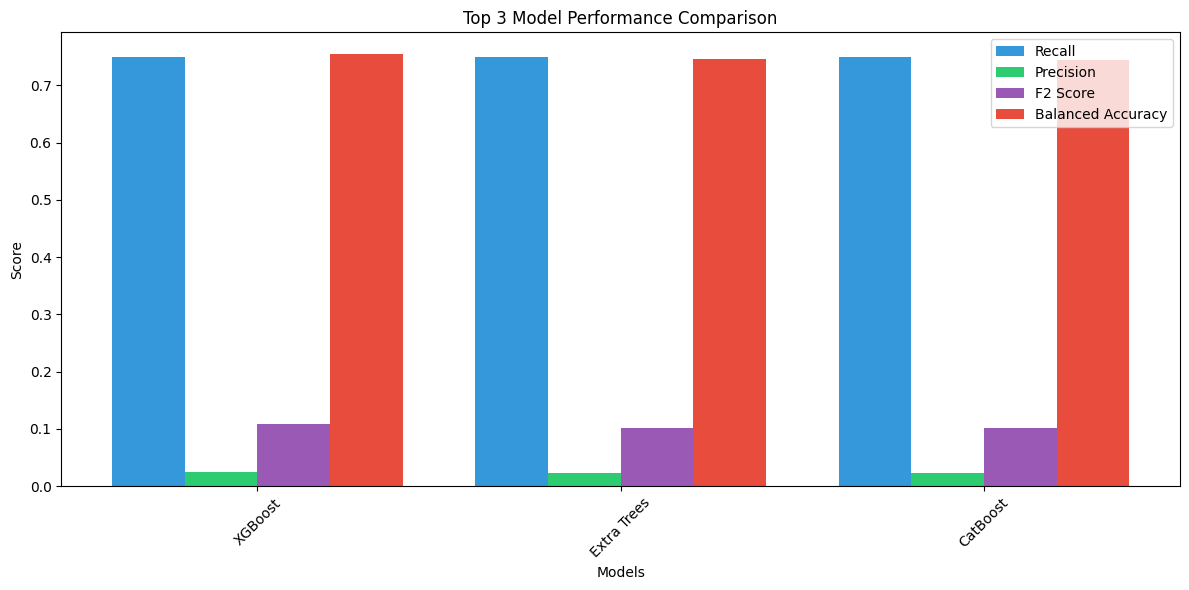

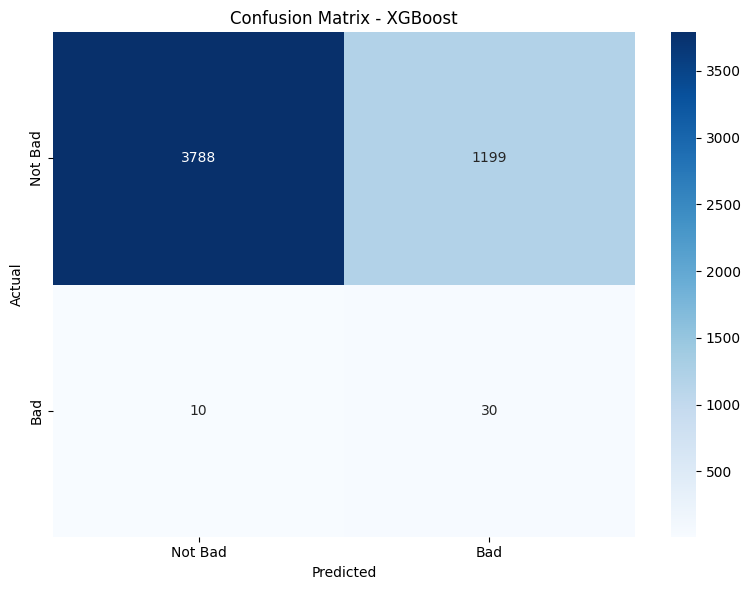


Classification Report for XGBoost Model:
              precision    recall  f1-score   support

           0       1.00      0.76      0.86      4987
           1       0.02      0.75      0.05        40

    accuracy                           0.76      5027
   macro avg       0.51      0.75      0.45      5027
weighted avg       0.99      0.76      0.86      5027



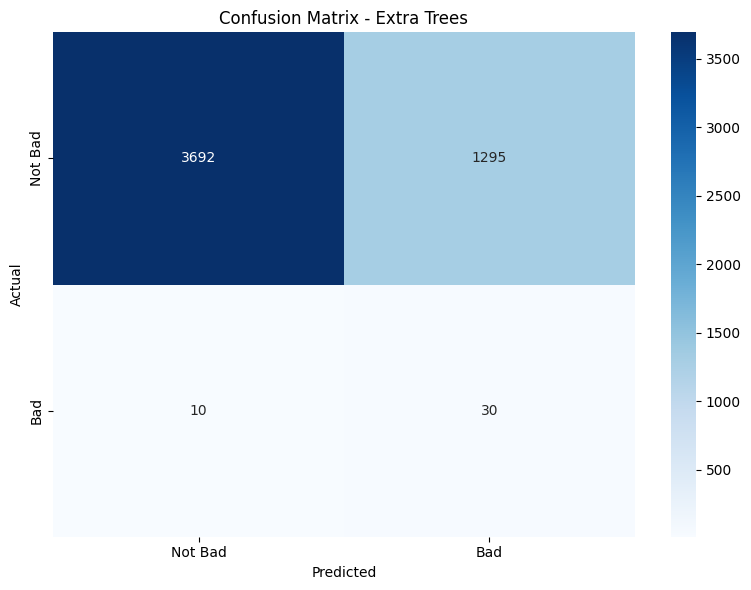


Classification Report for Extra Trees Model:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      4987
           1       0.02      0.75      0.04        40

    accuracy                           0.74      5027
   macro avg       0.51      0.75      0.45      5027
weighted avg       0.99      0.74      0.84      5027



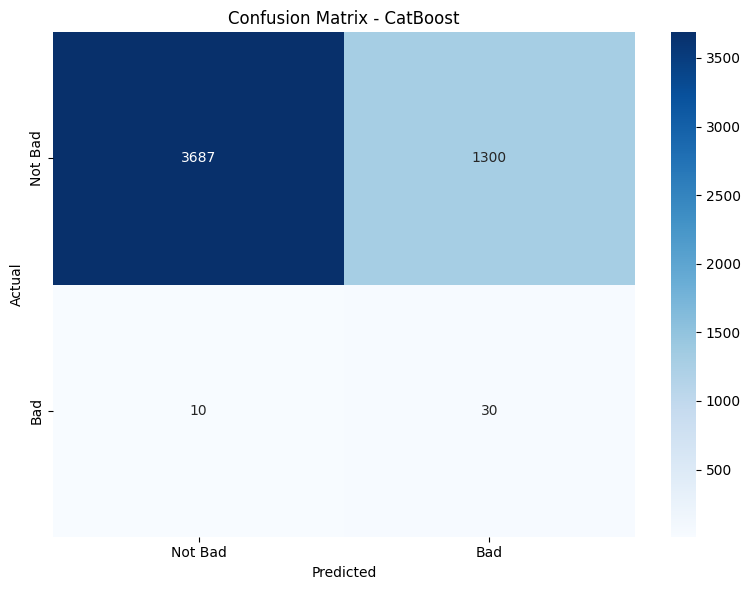


Classification Report for CatBoost Model:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      4987
           1       0.02      0.75      0.04        40

    accuracy                           0.74      5027
   macro avg       0.51      0.74      0.45      5027
weighted avg       0.99      0.74      0.84      5027



In [ ]:
def main():
    # # Step 1: Apply improved outlier removal
    # outlier_remover = OutlierRemover(features=outlier_features, iqr_multiplier=2.5)
    # train_filtered = outlier_remover.fit_transform(train_original) 
    
    # Step 2: Split features and target
    X_filtered, y_filtered = train_original.drop(columns=['IS_BAD']), train_original['IS_BAD']
    X_test, y_test = test_original.drop(columns=['IS_BAD']), test_original['IS_BAD']
    
    print(f"Training data shape after outlier removal: {X_filtered.shape}, {y_filtered.shape}")
    print(f"Class distribution after outlier removal: {y_filtered.value_counts(normalize=True)}")
    
    # Step 3: Apply preprocessing
    print("Applying preprocessing...")
    X_train_preprocessed = preprocessing_pipeline.fit_transform(X_filtered)
    X_test_preprocessed = preprocessing_pipeline.transform(X_test)
    
    # Step 4: Apply resampling
    print("Selecting the best resampling method...")
    resampling_methods = ['SMOTE', 'ADASYN', 'RandomOverSampler', 'SMOTETomek']
    
    # Quick evaluation of resampling methods with a simple model
    resampling_scores = []
    
    for method in resampling_methods:
        print(f"Testing {method}...")
        X_train_resampled, y_train_resampled = apply_resampling(X_train_preprocessed, y_filtered, method)
        
        # Use a simple RandomForest to evaluate the resampling method
        simple_rf = RandomForestClassifier(
            n_estimators=100, 
            class_weight={0:1, 1:10},
            random_state=42, 
            n_jobs=-1
        )
        simple_rf.fit(X_train_resampled, y_train_resampled)
        
        # Predict with a low threshold to ensure high recall
        y_proba = simple_rf.predict_proba(X_test_preprocessed)[:, 1]
        
        for threshold in np.arange(0.1, 0.01, -0.01):
            y_pred = (y_proba >= threshold)
            recall = recall_score(y_test, y_pred)
            if recall >= 0.75:
                break
        
        if 'threshold' not in locals():
            threshold = 0.01
            y_pred = (y_proba >= threshold)
            recall = recall_score(y_test, y_pred)
        
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        
        resampling_scores.append({
            'method': method,
            'recall': recall,
            'balanced_accuracy': balanced_acc,
            'f2_score': f2,
            'train_size': X_train_resampled.shape[0]
        })
    
    # Select the best resampling method based on F2 score
    resampling_scores_df = pd.DataFrame(resampling_scores)
    print("\nResampling methods comparison:")
    print(resampling_scores_df)
    
    # Select the resampling method with the highest F2 score that also achieves >75% recall
    valid_methods = resampling_scores_df[resampling_scores_df['recall'] >= 0.75]
    if len(valid_methods) > 0:
        best_resampling = valid_methods.sort_values('f2_score', ascending=False).iloc[0]['method']
    else:
        # If no method achieves 75% recall, pick the one with highest recall
        best_resampling = resampling_scores_df.sort_values('recall', ascending=False).iloc[0]['method']
    
    print(f"\nSelected resampling method: {best_resampling}")
    
    # Apply the best resampling method
    X_train_resampled, y_train_resampled = apply_resampling(X_train_preprocessed, y_filtered, best_resampling)
    print(f"Training data shape after preprocessing and resampling: {X_train_resampled.shape}")
    print(f"Class distribution after resampling: {np.bincount(y_train_resampled)}")
    
    # Step 5: Optimize classifiers using Optuna
    print("\nStarting Optuna hyperparameter optimization...")
    optimization_results = optimize_all_classifiers(
        X_train_resampled, 
        X_test_preprocessed, 
        y_train_resampled, 
        y_test, 
        n_trials=50  # You can adjust the number of trials based on available time
    )
    
    # Step 6: Select the top 3 models based on F2 score
    model_metrics = []
    
    for model_name, result in optimization_results.items():
        model_metrics.append({
            'model_name': model_name,
            'f2_score': result['metrics']['f2_score'],
            'recall': result['metrics']['recall'],
            'precision': result['metrics']['precision'],
            'balanced_accuracy': result['metrics']['balanced_accuracy'],
            'threshold': result['threshold']
        })
    
    # Create a dataframe of results
    metrics_df = pd.DataFrame(model_metrics)
    print("\nAll model results:")
    print(metrics_df.sort_values('f2_score', ascending=False))
    
    # Select top 3 models (ensuring they meet the recall criterion)
    valid_models = metrics_df[metrics_df['recall'] >= 0.75]
    if len(valid_models) >= 3:
        top_3_models = valid_models.sort_values('f2_score', ascending=False).head(3)
    else:
        # If fewer than 3 models meet the recall criterion, include models with highest recall
        top_3_models = metrics_df.sort_values('recall', ascending=False).head(3)
    
    print("\nTop 3 selected models:")
    print(top_3_models)
    

    return optimization_results, top_3_models

if __name__ == "__main__":
    
    # Run the main function with Optuna optimization
    optimization_results, top_models = main()
    
    # Display summary of results
    print("\n=== MODEL TRAINING SUMMARY ===")
    
    # 1. Best Model Information
    best_model_name = top_models.iloc[0]['model_name']
    best_threshold = top_models.iloc[0]['threshold']
    
    print(f"Best Model: {best_model_name}")
    print(f"Optimal Threshold: {best_threshold:.4f}")
    print(f"Best Hyperparameters: {optimization_results[best_model_name]['hyperparameters']}")
    
    # 2. Visualize Results - Create a comparison chart of metrics
    model_names = top_models['model_name'].tolist()
    recalls = top_models['recall'].tolist()
    precisions = top_models['precision'].tolist()
    f2_scores = top_models['f2_score'].tolist()
    balanced_accs = top_models['balanced_accuracy'].tolist()
    
    # Plot metrics comparison
    plt.figure(figsize=(12, 6))
    bar_width = 0.2
    x = np.arange(len(model_names))
    
    plt.bar(x - 1.5*bar_width, recalls, width=bar_width, label='Recall', color='#3498db')
    plt.bar(x - 0.5*bar_width, precisions, width=bar_width, label='Precision', color='#2ecc71')
    plt.bar(x + 0.5*bar_width, f2_scores, width=bar_width, label='F2 Score', color='#9b59b6')
    plt.bar(x + 1.5*bar_width, balanced_accs, width=bar_width, label='Balanced Accuracy', color='#e74c3c')
    
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.title('Top 3 Model Performance Comparison')
    plt.xticks(x, model_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 3. Display Confusion Matrix for Best Model
    y_test = test_original['IS_BAD']
    X_test_preprocessed = preprocessing_pipeline.transform(test_original.drop(columns=['IS_BAD']))
    
    for i, model_name in enumerate(model_names):
        # Get the model object and threshold
        model_object = optimization_results[model_name]['model']
        threshold = top_models.iloc[i]['threshold']
        
        # Make predictions
        y_proba = model_object.predict_proba(X_test_preprocessed)[:, 1]
        y_pred = (y_proba >= threshold)
        
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Not Bad', 'Bad'], 
                    yticklabels=['Not Bad', 'Bad'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.tight_layout()
        plt.show()
        
        # Generate a classification report
        print(f"\nClassification Report for {model_name} Model:")
        print(classification_report(y_test, y_pred))

    

In [57]:
# 5. Save all trained models
print("\nSaving trained models...")
    
# Specify save location
save_dir = r"D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\models\2nd_models"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist
    
# Buat dictionary untuk menyimpan model terbaik
trained_models = {}
optimal_thresholds = {}
    
# Ambil model terbaik dan thresholds dari hasil optimasi
for index, row in top_models.iterrows():
    model_name = row['model_name']
    threshold = row['threshold']
        
    # Simpan model dan threshold
    trained_models[model_name] = optimization_results[model_name]['model']
    optimal_thresholds[model_name] = threshold
    
# Ambil nama fitur dari preprocessing pipeline jika tersedia
try:
    # Coba dapatkan feature names dari preprocessing pipeline
    # Ini bergantung pada struktur pipeline Anda
    if hasattr(preprocessing_pipeline, 'get_feature_names_out'):
        feature_names = preprocessing_pipeline.get_feature_names_out()
    else:
        # Jika pipeline tidak memiliki get_feature_names_out, coba dari transformers
        for name, transform in preprocessing_pipeline.named_steps.items():
            if hasattr(transform, 'get_feature_names_out'):
                feature_names = transform.get_feature_names_out()
                break
        else:
            feature_names = None
except:
    feature_names = None
    
# Buat dictionary dengan semua komponen penting
model_data = {
    "models": trained_models,  # Model terbaik
    "preprocessing_pipeline": preprocessing_pipeline,  # Preprocessing pipeline
    "thresholds": optimal_thresholds,  # Threshold untuk setiap model terbaik
    "feature_names": feature_names  # Nama fitur
}
    
# Save to .pkl file
model_path = os.path.join(save_dir, "final_model.pkl")
joblib.dump(model_data, model_path)
    
print(f"\nModel terbaik dan data terkait telah berhasil disimpan di: {model_path}")


Saving trained models...



Model terbaik dan data terkait telah berhasil disimpan di: D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\models\2nd_models\final_model.pkl
